# Project 11 - Multimodal Fake News Detection
## Notebook 3:  Modeling and Evaluation Workflow

**Project title:** Fake-news classification with text, image, and image-text consistency signals.

This notebook is organized as two clearly separated parts:

1. **Legacy MS1 diagnostic workflow** - retained for reproducibility and milestone comparison. It uses all rows and may use gray image placeholders, so it is not the headline evaluation.
2. **Final  workflow** - uses credibility checks, valid-image-only/de-leaked splits, strong text baselines, optional pretrained text and CLIP alignment baselines, multimodal ablations, statistical comparison, and report artifacts.

**Important task note:** FakeNewsNet provides `fake`/`real` labels, not direct `consistent`/`inconsistent` labels. Therefore, image-text consistency features are used as evidence for fake/real classification, but the project should not claim direct inconsistency detection unless a dataset explicitly labels inconsistency.


## Notebook Outputs

Running the final workflow saves the most important report artifacts under `final_artifacts/`, including:

- `final_text_baselines_results.csv`
- `final_clip_alignment_results.csv` when CLIP is available
- `final_deep_ablation_results_all_seeds.csv`
- `final_deep_ablation_results_mean_std.csv`
- `final_image_content_leakage_audit.csv`
- `final_image_deleakage_split_filter_audit.csv`
- `final_valid_image_only_model_results.csv`
- `final_per_source_metrics.csv`
- `final_bootstrap_ci_macro_f1.csv`
- `final_mcnemar_tests.csv`
- `FINAL_REPORT_TABLE_model_comparison.csv`

The earlier MS1 outputs are still produced for reproducibility, but they should be presented as diagnostic/legacy results.


---
# Part I - Legacy MS1 Diagnostic Workflow

This section satisfies the original milestone flow: text-only baseline, simple multimodal CNN + text fusion, and qualitative failure cases. Because it can use placeholder images for missing visual data, use it as a diagnostic baseline, not the final claim.


In [150]:
# Optional install command, run only if the environment is missing packages:
# !pip install pandas numpy matplotlib seaborn scikit-learn Pillow torch torchvision tqdm --quiet

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('PyTorch:', torch.__version__)


Device: cuda
PyTorch: 2.12.0+cu132


In [151]:
# Experiment configuration
DATA_SPLIT_DIR = Path('data_splits')
SPLITS = ['train', 'val', 'test']
LABEL_TO_ID = {'real': 0, 'fake': 1}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}

MAX_TEXT_FEATURES = 512
IMAGE_SIZE = 128
BATCH_SIZE = 16
NUM_EPOCHS = 12
PATIENCE = 4
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# The original MS1 workflow uses all rows and gray placeholders for missing images.
# Keep it as a diagnostic/reproducibility experiment only. The final report should
# use the FINAL-UPGRADE valid-image-only section below for headline multimodal claims.
RUN_MULTIMODAL_TRAINING = True
MS1_PLACEHOLDER_DIAGNOSTIC_ONLY = True

print('Configuration loaded.')
if MS1_PLACEHOLDER_DIAGNOSTIC_ONLY:
    print('Note: the early MS1 multimodal run is diagnostic because it uses placeholder images for missing image paths.')


Configuration loaded.
Note: the early MS1 multimodal run is diagnostic because it uses placeholder images for missing image paths.


## Legacy Data Loading

In [152]:
def load_prepared_split(split_name: str, valid_only: bool = False) -> pd.DataFrame:
    """Load prepared splits.

    valid_only=False keeps the original all-sample MS1 diagnostic workflow.
    valid_only=True loads *_valid_images_only.csv for fair final multimodal claims.
    """
    candidates = []
    if valid_only:
        candidates.append(DATA_SPLIT_DIR / f'{split_name}_valid_images_only.csv')
    candidates.extend([
        DATA_SPLIT_DIR / f'{split_name}_multimodal.csv',
        DATA_SPLIT_DIR / f'{split_name}.csv',
    ])
    path = next((candidate for candidate in candidates if candidate.exists()), None)
    if path is None:
        raise FileNotFoundError(
            f'Missing prepared split for {split_name}. Run Notebook 01, then Notebook 02 if using images.'
        )

    df = pd.read_csv(path)
    df['split'] = split_name
    df['id'] = df['id'].astype(str)
    df['title'] = df['title'].fillna('').astype(str)
    df['label'] = df['label'].astype(str).str.lower().str.strip()
    df = df[df['label'].isin(LABEL_TO_ID)].copy()

    if 'image_path_primary' not in df.columns:
        df['image_path_primary'] = np.nan
    if 'has_image' not in df.columns:
        df['has_image'] = df['image_path_primary'].notna()
    if 'source' not in df.columns:
        df['source'] = 'unknown'

    df.attrs['loaded_from'] = str(path)
    return df.reset_index(drop=True)

train_df = load_prepared_split('train', valid_only=False)
val_df = load_prepared_split('val', valid_only=False)
test_df = load_prepared_split('test', valid_only=False)

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'{name:5s}: {len(df):4d} rows | labels: {df["label"].value_counts().to_dict()} | loaded_from: {df.attrs.get("loaded_from", "unknown")}')


train: 8843 rows | labels: {'real': 4498, 'fake': 4345} | loaded_from: data_splits\train_multimodal.csv
val  : 1016 rows | labels: {'real': 539, 'fake': 477} | loaded_from: data_splits\val_multimodal.csv
test : 1005 rows | labels: {'real': 528, 'fake': 477} | loaded_from: data_splits\test_multimodal.csv


## Legacy Dataset Audit

In [153]:
def image_path_exists(path_value) -> bool:
    if not isinstance(path_value, str) or not path_value.strip():
        return False
    return Path(path_value).exists()

for df in [train_df, val_df, test_df]:
    df['label_id'] = df['label'].map(LABEL_TO_ID)
    unmapped_count = df['label_id'].isna().sum()
    if unmapped_count > 0:
        print(f'Warning: {unmapped_count} rows have unmapped labels. Dropping them.')
        df.drop(df[df['label_id'].isna()].index, inplace=True)
        df.reset_index(drop=True, inplace=True)
    df['label_id'] = df['label_id'].astype(int)
    df['valid_image_path'] = df['image_path_primary'].apply(image_path_exists)
    df['has_image'] = df['valid_image_path']

summary_rows = []
source_label_rows = []
for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    summary_rows.append({
        'split': split_name,
        'n_rows': len(df),
        'fake': int((df['label'] == 'fake').sum()),
        'real': int((df['label'] == 'real').sum()),
        'valid_images': int(df['valid_image_path'].sum()),
        'image_coverage_%': round(100 * df['valid_image_path'].mean(), 2),
        'unique_sources': int(df['source'].nunique()),
        'data_policy': 'all_samples_with_gray_placeholder_for_missing_images',
    })
    grp = df.groupby(['source','label']).agg(
        n_rows=('id','size'),
        valid_images=('valid_image_path','sum')
    ).reset_index()
    grp['split'] = split_name
    grp['image_coverage_%'] = (100 * grp['valid_images'] / grp['n_rows']).round(2)
    source_label_rows.append(grp[['split','source','label','n_rows','valid_images','image_coverage_%']])

audit_df = pd.DataFrame(summary_rows)
display(audit_df)
audit_df.to_csv('ms1_dataset_audit.csv', index=False)
pd.concat(source_label_rows, ignore_index=True).to_csv('final_artifacts/ms1_placeholder_image_coverage_by_split_source_label.csv', index=False)

print('\nImportant for report: this early MS1 run is diagnostic. Missing images are handled with a neutral gray placeholder, and EDA shows image availability is uneven by source/label.')
print('Use the FINAL-UPGRADE valid-image-only section for headline multimodal image-evidence claims.')


,split,n_rows,fake,real,valid_images,image_coverage_%,unique_sources,data_policy
0,train,8843,4345,4498,4553,51.49,2,all_samples_with_gray_placeholder_for_missing_images
1,val,1016,477,539,540,53.15,2,all_samples_with_gray_placeholder_for_missing_images
2,test,1005,477,528,514,51.14,2,all_samples_with_gray_placeholder_for_missing_images



Important for report: this early MS1 run is diagnostic. Missing images are handled with a neutral gray placeholder, and EDA shows image availability is uneven by source/label.
Use the FINAL-UPGRADE valid-image-only section for headline multimodal image-evidence claims.


## Legacy Text-Only Baseline

In [154]:
# This baseline is intentionally simple, fast, and strong enough for comparison.
# It directly addresses the deliverable: "text-only baseline".

vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    ngram_range=(1, 2),
    max_features=MAX_TEXT_FEATURES,
    min_df=1,
    stop_words='english',
)

X_train_text = vectorizer.fit_transform(train_df['title'])
X_val_text = vectorizer.transform(val_df['title'])
X_test_text = vectorizer.transform(test_df['title'])
y_train = train_df['label_id'].to_numpy()
y_val = val_df['label_id'].to_numpy()
y_test = test_df['label_id'].to_numpy()

text_clf = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED,
    solver='liblinear',
)
text_clf.fit(X_train_text, y_train)

text_val_pred = text_clf.predict(X_val_text)
text_test_pred = text_clf.predict(X_test_text)
text_test_proba = text_clf.predict_proba(X_test_text).max(axis=1)

def compute_metrics(y_true, y_pred, prefix):
    return {
        f'{prefix}_accuracy': accuracy_score(y_true, y_pred),
        f'{prefix}_macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        f'{prefix}_precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        f'{prefix}_recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }

text_metrics = {}
text_metrics.update(compute_metrics(y_val, text_val_pred, 'val'))
text_metrics.update(compute_metrics(y_test, text_test_pred, 'test'))
print('Text-only baseline metrics:')
for k, v in text_metrics.items():
    print(f'  {k}: {v:.4f}')

print('\nText-only test classification report:')
print(classification_report(y_test, text_test_pred, target_names=['real', 'fake'], zero_division=0))

text_predictions_df = test_df[['id', 'source', 'title', 'label']].copy()
text_predictions_df['text_pred_label'] = [ID_TO_LABEL[i] for i in text_test_pred]
text_predictions_df['text_confidence'] = text_test_proba
text_predictions_df['text_correct'] = text_predictions_df['label'].eq(text_predictions_df['text_pred_label'])
text_predictions_df.to_csv('ms1_text_only_test_predictions.csv', index=False)

display(text_predictions_df.head())


Text-only baseline metrics:
  val_accuracy: 0.7411
  val_macro_f1: 0.7397
  val_precision_macro: 0.7403
  val_recall_macro: 0.7394
  test_accuracy: 0.7473
  test_macro_f1: 0.7464
  test_precision_macro: 0.7467
  test_recall_macro: 0.7462

Text-only test classification report:
              precision    recall  f1-score   support

        real       0.76      0.77      0.76       528
        fake       0.74      0.73      0.73       477

    accuracy                           0.75      1005
   macro avg       0.75      0.75      0.75      1005
weighted avg       0.75      0.75      0.75      1005



,id,source,title,label,text_pred_label,text_confidence,text_correct
0,gossipcop-921650,gossipcop,Megan Fox gets emotional on Hollywood Medium,real,real,0.703957,True
1,gossipcop-2502492072,gossipcop,Kylie Jenner: Why She’s Crying Herself To Sleep Over Delivery Room Drama,fake,fake,0.553284,True
2,gossipcop-3349415808,gossipcop,8 Juiciest Celebrity Feuds of 2017,fake,fake,0.601461,True
3,gossipcop-943749,gossipcop,2018 MTV Movie and TV Awards: Complete List of Winners,real,real,0.769012,True
4,gossipcop-7661930332,gossipcop,Angela Kardashian Angela Kardashian,fake,fake,0.690736,True


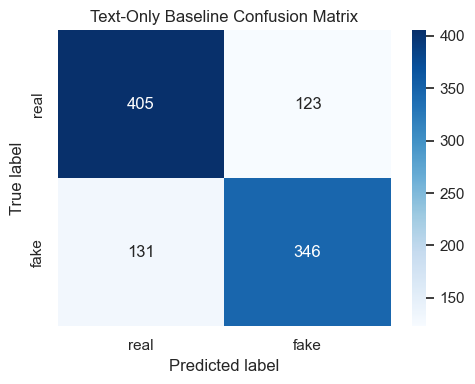

In [155]:
cm_text = confusion_matrix(y_test, text_test_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_text, annot=True, fmt='d', cmap='Blues', xticklabels=['real', 'fake'], yticklabels=['real', 'fake'])
plt.title('Text-Only Baseline Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.savefig('plot_10_text_baseline_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


## Legacy Multimodal Dataset Preparation

In [156]:
# Convert TF-IDF vectors to dense text embeddings for the PyTorch fusion model.
# This is a lightweight embedding representation suitable for MS1.

X_train_dense = X_train_text.astype(np.float32).toarray()
X_val_dense = X_val_text.astype(np.float32).toarray()
X_test_dense = X_test_text.astype(np.float32).toarray()

print('Text embedding dimension:', X_train_dense.shape[1])

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class FakeNewsMultimodalDataset(Dataset):
    """Returns a title embedding, an image tensor, label, and metadata.

    If an image is missing or unreadable, the dataset returns a neutral gray image.
    This keeps the experiment reproducible even when image coverage is incomplete.
    """
    def __init__(self, dataframe, text_features, transform):
        self.df = dataframe.reset_index(drop=True).copy()
        self.text_features = text_features.astype(np.float32)
        self.transform = transform
        # Store metadata separately for later retrieval (not used in training loop)
        self.metadata = dataframe[['id', 'title', 'label', 'source']].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def _load_image(self, path_value):
        if isinstance(path_value, str) and path_value.strip() and Path(path_value).exists():
            try:
                return Image.open(path_value).convert('RGB')
            except Exception:
                pass
        return Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), (128, 128, 128))

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_image(row.get('image_path_primary', np.nan))
        img = self.transform(img)
        text_vec = torch.tensor(self.text_features[idx], dtype=torch.float32)
        label = torch.tensor(int(row['label_id']), dtype=torch.long)
        # Return only tensor data; metadata is stored separately
        return {
            'text': text_vec,
            'image': img,
            'label': label,
        }

train_dataset = FakeNewsMultimodalDataset(train_df, X_train_dense, train_transform)
val_dataset = FakeNewsMultimodalDataset(val_df, X_val_dense, eval_transform)
test_dataset = FakeNewsMultimodalDataset(test_df, X_test_dense, eval_transform)

class_counts = np.bincount(y_train, minlength=2)
class_weights_np = len(y_train) / (2 * np.maximum(class_counts, 1))
sample_weights = class_weights_np[y_train]
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Class counts:', dict(zip(['real', 'fake'], class_counts.tolist())))
print('Class weights:', class_weights_np.round(3).tolist())
print('Batches:', {'train': len(train_loader), 'val': len(val_loader), 'test': len(test_loader)})

Text embedding dimension: 512
Class counts: {'real': 4498, 'fake': 4345}
Class weights: [0.983, 1.018]
Batches: {'train': 553, 'val': 64, 'test': 63}


## Legacy CNN + Text Fusion Model

In [157]:
class SmallCNNEncoder(nn.Module):
    """A lightweight CNN image encoder suitable for a small MS1 dataset."""
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.proj = nn.Linear(128, out_dim)

    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.proj(x)


class ConsistencyFusionNet(nn.Module):
    """Fuse text and image features using explicit cross-modal consistency terms.

    The model projects image and text into the same latent dimension, then uses:
    - text vector
    - image vector
    - absolute difference |text - image|
    - element-wise product text * image

    The difference and product terms encourage the classifier to learn agreement or
    mismatch between the headline/text representation and the visual representation.
    """
    def __init__(self, text_dim, latent_dim=128, num_classes=2, dropout=0.35):
        super().__init__()
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, latent_dim),
            nn.BatchNorm1d(latent_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.image_encoder = SmallCNNEncoder(out_dim=latent_dim)
        self.image_proj = nn.Sequential(
            nn.BatchNorm1d(latent_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        fusion_dim = latent_dim * 4
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, text, image):
        text_z = self.text_proj(text)
        image_z = self.image_proj(self.image_encoder(image))
        diff = torch.abs(text_z - image_z)
        prod = text_z * image_z
        fused = torch.cat([text_z, image_z, diff, prod], dim=1)
        return self.classifier(fused)

model = ConsistencyFusionNet(text_dim=X_train_dense.shape[1]).to(DEVICE)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Trainable parameters: {trainable_params:,}')


ConsistencyFusionNet(
  (text_proj): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.35, inplace=False)
  )
  (image_encoder): SmallCNNEncoder(
    (features): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2

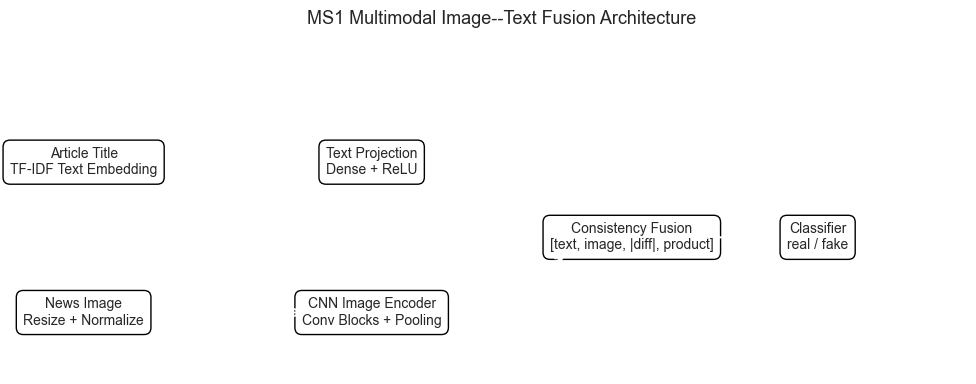

In [158]:
# Architecture diagram for the Methodology section of the report.
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
boxes = [
    (0.05, 0.62, 'Article Title\nTF-IDF Text Embedding'),
    (0.05, 0.18, 'News Image\nResize + Normalize'),
    (0.36, 0.62, 'Text Projection\nDense + ReLU'),
    (0.36, 0.18, 'CNN Image Encoder\nConv Blocks + Pooling'),
    (0.64, 0.40, 'Consistency Fusion\n[text, image, |diff|, product]'),
    (0.84, 0.40, 'Classifier\nreal / fake'),
]
for x, y, label in boxes:
    ax.text(x, y, label, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black'))

def arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='->', lw=1.5))
arrow(0.18, 0.62, 0.29, 0.62)
arrow(0.18, 0.18, 0.29, 0.18)
arrow(0.48, 0.62, 0.57, 0.47)
arrow(0.48, 0.18, 0.57, 0.35)
arrow(0.73, 0.40, 0.79, 0.40)
ax.set_title('MS1 Multimodal Image--Text Fusion Architecture', fontsize=13)
plt.tight_layout()
plt.savefig('plot_11_model_architecture.png', dpi=150, bbox_inches='tight')
plt.show()


## Legacy Training Loop

In [159]:
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE))
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)


def run_epoch(model, dataloader, criterion=None, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses, all_preds, all_labels, all_probs = [], [], [], []

    for batch in dataloader:
        text = batch['text'].to(DEVICE)
        image = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(text, image)
            loss = criterion(logits, labels) if criterion is not None else None
            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        if loss is not None:
            losses.append(loss.item())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_probs.extend(probs.max(dim=1).values.detach().cpu().numpy().tolist())

    metrics = {
        'loss': float(np.mean(losses)) if losses else np.nan,
        'accuracy': accuracy_score(all_labels, all_preds),
        'macro_f1': f1_score(all_labels, all_preds, average='macro', zero_division=0),
    }
    return metrics, np.array(all_preds), np.array(all_labels), np.array(all_probs)

history = []
best_val_f1 = -1.0  # Initialize as float
best_epoch = 0
patience_counter = 0
best_path = Path('best_ms1_multimodal_model.pt')

if RUN_MULTIMODAL_TRAINING:
    for epoch in range(1, NUM_EPOCHS + 1):
        train_metrics, _, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_metrics, _, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step(val_metrics['macro_f1'])

        row = {'epoch': epoch, **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'val_{k}': v for k, v in val_metrics.items()}}
        history.append(row)
        print(f"Epoch {epoch:02d} | train loss={train_metrics['loss']:.4f}, train F1={train_metrics['macro_f1']:.3f} | val F1={val_metrics['macro_f1']:.3f}, val acc={val_metrics['accuracy']:.3f}")

        if val_metrics['macro_f1'] > best_val_f1:
            best_val_f1 = val_metrics['macro_f1']
            best_epoch = epoch
            patience_counter = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'text_dim': X_train_dense.shape[1],
                'vectorizer_vocabulary': vectorizer.vocabulary_,
                'label_to_id': LABEL_TO_ID,
                'config': {
                    'image_size': IMAGE_SIZE,
                    'max_text_features': MAX_TEXT_FEATURES,
                    'latent_dim': 128,
                }
            }, best_path)
            print('  saved best model')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'Early stopping at epoch {epoch}. Best epoch: {best_epoch}')
                break
else:
    print('RUN_MULTIMODAL_TRAINING=False. Skipping neural model training.')

history_df = pd.DataFrame(history)
if not history_df.empty:
    display(history_df)
    history_df.to_csv('ms1_training_history.csv', index=False)

Epoch 01 | train loss=0.5679, train F1=0.701 | val F1=0.732, val acc=0.733
  saved best model
Epoch 02 | train loss=0.5113, train F1=0.753 | val F1=0.709, val acc=0.709
Epoch 03 | train loss=0.4875, train F1=0.769 | val F1=0.739, val acc=0.741
  saved best model
Epoch 04 | train loss=0.4705, train F1=0.785 | val F1=0.717, val acc=0.718
Epoch 05 | train loss=0.4571, train F1=0.779 | val F1=0.733, val acc=0.734
Epoch 06 | train loss=0.4473, train F1=0.788 | val F1=0.735, val acc=0.735
Epoch 07 | train loss=0.4166, train F1=0.804 | val F1=0.733, val acc=0.734
Early stopping at epoch 7. Best epoch: 3


,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1
0,1,0.567889,0.701006,0.700650,0.546930,0.733268,0.731727
1,2,0.511279,0.753364,0.753267,0.559296,0.708661,0.708651
2,3,0.487460,0.768970,0.768896,0.552721,0.741142,0.738558
3,4,0.470492,0.785254,0.784921,0.558427,0.717520,0.716861
4,5,0.457087,0.779260,0.779168,0.538961,0.734252,0.733126
5,6,0.447289,0.788081,0.787805,0.565923,0.735236,0.734846
6,7,0.416632,0.804139,0.804118,0.575531,0.734252,0.733126


## Legacy Model Evaluation

In [160]:
if best_path.exists():
    checkpoint = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'Loaded best model from {best_path}')
else:
    print('No saved multimodal checkpoint found. Using current model weights.')

mm_test_metrics, mm_test_pred, mm_test_labels, mm_test_conf = run_epoch(model, test_loader, criterion=None, optimizer=None)
print('Multimodal test metrics:')
for k, v in mm_test_metrics.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

print('\nMultimodal test classification report:')
print(classification_report(mm_test_labels, mm_test_pred, target_names=['real', 'fake'], zero_division=0))

mm_predictions_df = test_df[['id', 'source', 'title', 'label', 'image_path_primary', 'valid_image_path']].copy()
mm_predictions_df['mm_pred_label'] = [ID_TO_LABEL[i] for i in mm_test_pred]
mm_predictions_df['mm_confidence'] = mm_test_conf
mm_predictions_df['mm_correct'] = mm_predictions_df['label'].eq(mm_predictions_df['mm_pred_label'])
mm_predictions_df.to_csv('ms1_multimodal_test_predictions.csv', index=False)

display(mm_predictions_df.head())

Loaded best model from best_ms1_multimodal_model.pt
Multimodal test metrics:
  loss: nan
  accuracy: 0.7423
  macro_f1: 0.7390

Multimodal test classification report:
              precision    recall  f1-score   support

        real       0.73      0.81      0.77       528
        fake       0.76      0.66      0.71       477

    accuracy                           0.74      1005
   macro avg       0.75      0.74      0.74      1005
weighted avg       0.74      0.74      0.74      1005



,id,source,title,label,image_path_primary,valid_image_path,mm_pred_label,mm_confidence,mm_correct
0,gossipcop-921650,gossipcop,Megan Fox gets emotional on Hollywood Medium,real,images\test\gossipcop-921650_0_cc9c873a42.jpg,True,real,0.764489,True
1,gossipcop-2502492072,gossipcop,Kylie Jenner: Why She’s Crying Herself To Sleep Over Delivery Room Drama,fake,NaN,False,real,0.520211,False
2,gossipcop-3349415808,gossipcop,8 Juiciest Celebrity Feuds of 2017,fake,images\test\gossipcop-3349415808_0_ff69e4cb8f.jpg,True,fake,0.597599,True
3,gossipcop-943749,gossipcop,2018 MTV Movie and TV Awards: Complete List of Winners,real,images\test\gossipcop-943749_0_8ba5405211.jpg,True,real,0.837209,True
4,gossipcop-7661930332,gossipcop,Angela Kardashian Angela Kardashian,fake,NaN,False,fake,0.560750,True


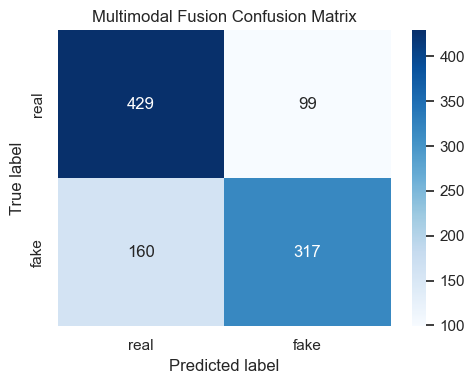

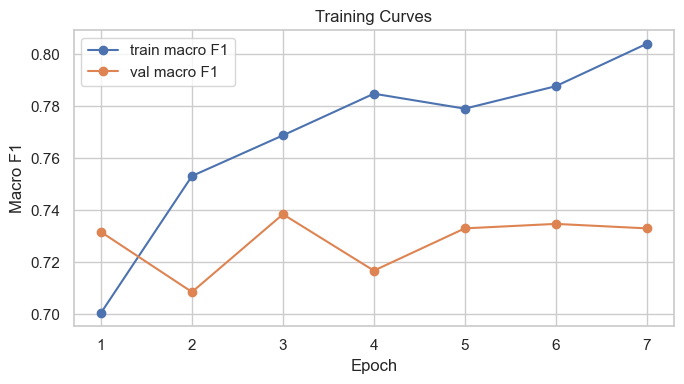

In [161]:
cm_mm = confusion_matrix(mm_test_labels, mm_test_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_mm, annot=True, fmt='d', cmap='Blues', xticklabels=['real', 'fake'], yticklabels=['real', 'fake'])
plt.title('Multimodal Fusion Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.savefig('plot_12_multimodal_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

if not history_df.empty:
    plt.figure(figsize=(7, 4))
    plt.plot(history_df['epoch'], history_df['train_macro_f1'], marker='o', label='train macro F1')
    plt.plot(history_df['epoch'], history_df['val_macro_f1'], marker='o', label='val macro F1')
    plt.title('Training Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Macro F1')
    plt.legend()
    plt.tight_layout()
    plt.savefig('plot_13_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


In [162]:
results_summary = pd.DataFrame([
    {
        'model': 'Text-only TF-IDF + Logistic Regression',
        'val_accuracy': text_metrics['val_accuracy'],
        'val_macro_f1': text_metrics['val_macro_f1'],
        'test_accuracy': text_metrics['test_accuracy'],
        'test_macro_f1': text_metrics['test_macro_f1'],
        'notes': 'Baseline required by project deliverables',
    },
    {
        'model': 'Multimodal CNN + Text Embedding Consistency Fusion',
        'val_accuracy': history_df['val_accuracy'].max() if not history_df.empty else np.nan,
        'val_macro_f1': history_df['val_macro_f1'].max() if not history_df.empty else np.nan,
        'test_accuracy': mm_test_metrics['accuracy'],
        'test_macro_f1': mm_test_metrics['macro_f1'],
        'notes': 'Uses image features, text embeddings, |difference|, and product fusion terms',
    },
])

results_summary.to_csv('ms1_results_summary.csv', index=False)
display(results_summary)

if results_summary.loc[1, 'test_macro_f1'] >= results_summary.loc[0, 'test_macro_f1']:
    print('The multimodal model matches or improves on the text-only baseline on test macro F1.')
else:
    print('The text-only baseline is stronger in this run; report this honestly and discuss limited image coverage / small data as likely reasons.')


,model,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,notes
0,Text-only TF-IDF + Logistic Regression,0.741142,0.739723,0.747264,0.746390,Baseline required by project deliverables
1,Multimodal CNN + Text Embedding Consistency Fusion,0.741142,0.738558,0.742289,0.739048,"Uses image features, text embeddings, |difference|, and product fusion terms"


The text-only baseline is stronger in this run; report this honestly and discuss limited image coverage / small data as likely reasons.


## Legacy Qualitative Failure Analysis

In [163]:
# Required by the project: qualitative analysis of failure cases.
# We save all mistakes and display the most confident mistakes.

errors_df = mm_predictions_df[~mm_predictions_df['mm_correct']].copy()
errors_df = errors_df.sort_values('mm_confidence', ascending=False)
errors_df.to_csv('ms1_failure_cases.csv', index=False)

print(f'Multimodal errors: {len(errors_df)} out of {len(mm_predictions_df)} test samples')
if len(errors_df):
    display(errors_df[['id', 'source', 'title', 'label', 'mm_pred_label', 'mm_confidence', 'valid_image_path']].head(10))
else:
    print('No test errors in this run. Displaying lowest-confidence correct cases instead.')
    display(mm_predictions_df.sort_values('mm_confidence').head(10)[['id', 'source', 'title', 'label', 'mm_pred_label', 'mm_confidence', 'valid_image_path']])


Multimodal errors: 259 out of 1005 test samples


,id,source,title,label,mm_pred_label,mm_confidence,valid_image_path
476,gossipcop-2656814899,gossipcop,Met Gala 2018: Madonna snacks while getting glammed up,fake,real,0.983290,True
897,gossipcop-921537,gossipcop,Selena Gomez Brings a Ukulele and a Bikini to Australia–but Not Justin Bieber,real,fake,0.981251,False
594,gossipcop-7259603960,gossipcop,Affordable Fashion & Style Blog,fake,real,0.980756,False
950,gossipcop-6345761457,gossipcop,Celebrities pay tribute to Mary Tyler Moore,fake,real,0.978209,True
177,gossipcop-2932564057,gossipcop,"VIDEO: Fifth Harmony Perform, Play 'Flinch' on LATE LATE SHOW Video",fake,real,0.977875,True
107,gossipcop-8092575981,gossipcop,The Bachelorette: Becca 'Frustrated' That Tia Still Has Feelings for Colton,fake,real,0.976228,True
816,gossipcop-9131837077,gossipcop,"Get a grip teenagers! You've got a few GCSEs not a role on Netflix, says LIZ JONES",fake,real,0.973622,True
775,gossipcop-3623255149,gossipcop,UPDATE: Steven Tyler Denies Seizure Reports,fake,real,0.972046,True
768,gossipcop-9093685718,gossipcop,Vito Schnabel Shares His Heartbreak Over Heidi Klum Split,fake,real,0.964386,True
944,gossipcop-952215,gossipcop,Blake Shelton Falls on Stage and It May Just Be Pitbull's Fault,real,fake,0.961011,False


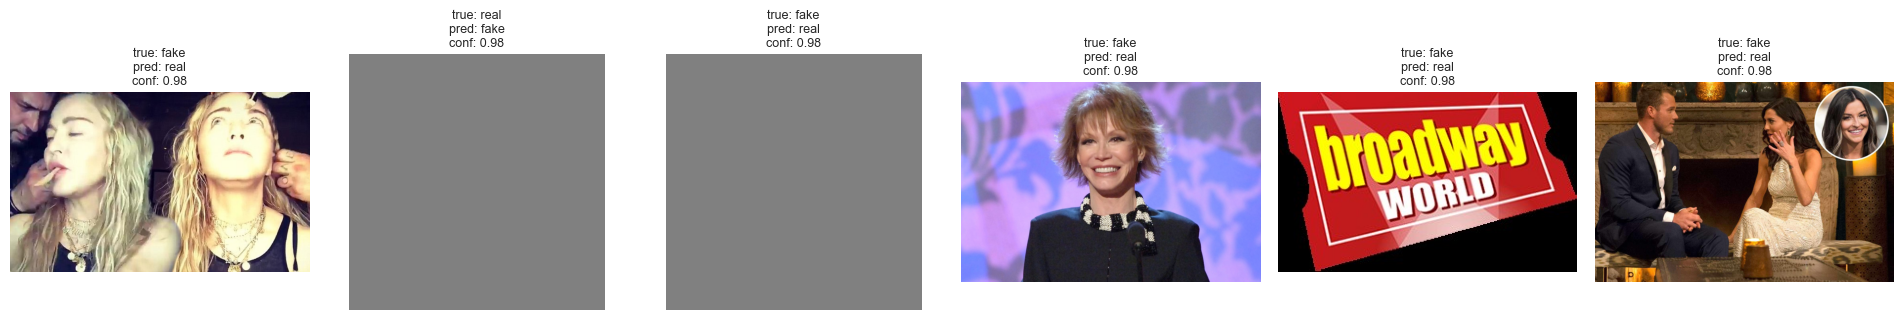

In [164]:
def show_failure_images(df, max_cases=6):
    subset = df.head(max_cases)
    if subset.empty:
        return
    n = len(subset)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.2))
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, subset.iterrows()):
        path = row.get('image_path_primary', '')
        if isinstance(path, str) and Path(path).exists():
            img = Image.open(path).convert('RGB')
        else:
            img = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), (128, 128, 128))
        ax.imshow(img)
        ax.axis('off')
        title = f"true: {row['label']}\npred: {row['mm_pred_label']}\nconf: {row['mm_confidence']:.2f}"
        ax.set_title(title, fontsize=9)
    plt.tight_layout()
    plt.savefig('plot_14_failure_cases.png', dpi=150, bbox_inches='tight')
    plt.show()

if len(errors_df):
    show_failure_images(errors_df, max_cases=6)
else:
    show_failure_images(mm_predictions_df.sort_values('mm_confidence').head(6), max_cases=6)


### How to Discuss Failure Cases in the Report

Use the saved `ms1_failure_cases.csv` file and the displayed examples above. Common explanations to check manually:

- The image is generic, low quality, or missing, so the model cannot verify the claim visually.
- The title is short or ambiguous, so the text representation is weak.
- The image looks semantically related to the title, but the article is labeled fake because of factual details not visible in the image.
- The model may learn domain/source artifacts because FakeNewsNet contains strong source and domain bias.
- Limited image coverage can make the multimodal model behave similarly to a text-only model.


## Legacy Summary

In [165]:
print('=' * 80)
print('MS1 EXPERIMENT SUMMARY')
print('=' * 80)
print('\nDataset:')
for _, row in audit_df.iterrows():
    print(f"  {row['split']}: n={row['n_rows']}, fake={row['fake']}, real={row['real']}, valid images={row['valid_images']} ({row['image_coverage_%']}%)")

print('\nModels implemented:')
print('  1. Text-only baseline: TF-IDF title embeddings + Logistic Regression')
print('  2. Multimodal model: CNN image encoder + text embeddings + consistency fusion')

print('\nMain comparison:')
for _, row in results_summary.iterrows():
    print(f"  {row['model']}: test accuracy={row['test_accuracy']:.3f}, test macro F1={row['test_macro_f1']:.3f}")

print('\nSaved outputs:')
for path in [
    'ms1_dataset_audit.csv',
    'ms1_text_only_test_predictions.csv',
    'ms1_multimodal_test_predictions.csv',
    'ms1_results_summary.csv',
    'ms1_failure_cases.csv',
    'best_ms1_multimodal_model.pt',
    'plot_10_text_baseline_confusion.png',
    'plot_11_model_architecture.png',
    'plot_12_multimodal_confusion.png',
    'plot_13_training_curves.png',
    'plot_14_failure_cases.png',
]:
    if Path(path).exists():
        print(' ', path)

print('\nPlanned improvements after MS1:')
print('  - Increase the number of valid downloaded images.')
print('  - Replace TF-IDF with transformer embeddings if GPU/time allow.')
print('  - Add ablations: image-only, text-only, early fusion, late fusion.')
print('  - Perform deeper manual annotation of image-text consistency examples.')
print('=' * 80)


MS1 EXPERIMENT SUMMARY

Dataset:
  train: n=8843, fake=4345, real=4498, valid images=4553 (51.49%)
  val: n=1016, fake=477, real=539, valid images=540 (53.15%)
  test: n=1005, fake=477, real=528, valid images=514 (51.14%)

Models implemented:
  1. Text-only baseline: TF-IDF title embeddings + Logistic Regression
  2. Multimodal model: CNN image encoder + text embeddings + consistency fusion

Main comparison:
  Text-only TF-IDF + Logistic Regression: test accuracy=0.747, test macro F1=0.746
  Multimodal CNN + Text Embedding Consistency Fusion: test accuracy=0.742, test macro F1=0.739

Saved outputs:
  ms1_dataset_audit.csv
  ms1_text_only_test_predictions.csv
  ms1_multimodal_test_predictions.csv
  ms1_results_summary.csv
  ms1_failure_cases.csv
  best_ms1_multimodal_model.pt
  plot_10_text_baseline_confusion.png
  plot_11_model_architecture.png
  plot_12_multimodal_confusion.png
  plot_13_training_curves.png
  plot_14_failure_cases.png

Planned improvements after MS1:
  - Increase the 

---
# Part II - Final Senior Workflow

This is the report-grade section. It uses de-leaked, valid-image-aware splits; audits hidden leakage; compares strong text baselines, optional DistilBERT, optional CLIP image-text alignment, and multimodal ablations; then produces confidence intervals, McNemar tests, per-source metrics, and report tables.

Recommended execution order for final results: run from `FINAL UPGRADE 03-A` through `FINAL UPGRADE 03-L` top-to-bottom.


In [166]:
# FINAL UPGRADE 03-A: Global final experiment configuration
from pathlib import Path
import os, json, math, random, time
import numpy as np
import pandas as pd

FINAL_ARTIFACT_DIR = Path('final_artifacts')
FINAL_ARTIFACT_DIR.mkdir(exist_ok=True)
DATA_SPLIT_DIR = Path('data_splits')

RUN_FINAL_DEEP_TRAINING = True
FINAL_EPOCHS = 8
FINAL_SEEDS = [42, 123, 2026]
VALID_IMAGE_ONLY_EVAL = True
USE_VALID_IMAGE_ONLY_FOR_FINAL_MODELS = True  # Avoid placeholder-image confounding for headline multimodal results.
USE_IMAGE_DELEAKED_SPLITS = True  # After the image hash audit, reload splits with prior-split image duplicates removed.
RUN_OPTIONAL_BERT_TEXT_BASELINE = True  # Runs only when transformers is installed and model weights are available.
RUN_OPTIONAL_CLIP_ALIGNMENT_BASELINE = True  # Tests image-text semantic agreement when CLIP weights are available.
INCLUDE_LEGACY_ROOT_TRIALS_IN_REPORT_TABLE = False  # Keep old pre-cleaning root trials out of headline tables by default.
RUN_RESNET50_FROZEN = True
FINAL_EARLY_STOPPING_PATIENCE = 3
FINAL_MIN_DELTA = 1e-4
FINAL_CNN_LR = 1e-3
FINAL_PRETRAINED_HEAD_LR = 1e-4
FINAL_WEIGHT_DECAY = 1e-4
FINAL_LABEL_SMOOTHING = 0.05
CLIP_MODEL_NAME = 'openai/clip-vit-base-patch32'
CLIP_BATCH_SIZE = 24
CLIP_MAX_TEXT_TOKENS = 77
LABEL_TO_ID = {'real': 0, 'fake': 1}
ID_TO_LABEL = {0: 'real', 1: 'fake'}

def set_all_seeds(seed=42):
    random.seed(seed); np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass

set_all_seeds(42)
print('Final experiment configuration saved.')
if USE_VALID_IMAGE_ONLY_FOR_FINAL_MODELS:
    print('Final deep/text comparisons will prefer data_splits/*_valid_images_only.csv when available.')
print(f'Early stopping: patience={FINAL_EARLY_STOPPING_PATIENCE}, min_delta={FINAL_MIN_DELTA}')

Final experiment configuration saved.
Final deep/text comparisons will prefer data_splits/*_valid_images_only.csv when available.
Early stopping: patience=3, min_delta=0.0001


In [167]:
# FINAL UPGRADE 03-B: Robust split loading and validation
from pathlib import Path
import pandas as pd, numpy as np

def load_final_split(split, valid_only=False):
    candidates = []
    if valid_only:
        candidates.append(DATA_SPLIT_DIR/f'{split}_valid_images_only.csv')
    candidates += [DATA_SPLIT_DIR/f'{split}_multimodal.csv', DATA_SPLIT_DIR/f'{split}.csv']
    for p in candidates:
        if p.exists():
            df = pd.read_csv(p)
            df['split'] = split
            if 'label_id' not in df.columns:
                df['label_id'] = df['label'].map(LABEL_TO_ID)
            if 'valid_image_path' not in df.columns:
                def _exists(x):
                    return isinstance(x, str) and Path(x).exists()
                path_col = 'image_path_primary' if 'image_path_primary' in df.columns else 'image_path' if 'image_path' in df.columns else None
                df['valid_image_path'] = df[path_col].apply(_exists) if path_col else False
            if valid_only:
                df = df[df['valid_image_path'].astype(bool)].reset_index(drop=True)
            return df
    raise FileNotFoundError(f'No file found for split={split}, valid_only={valid_only}; looked at {candidates}')

train_final = load_final_split('train', valid_only=USE_VALID_IMAGE_ONLY_FOR_FINAL_MODELS)
val_final = load_final_split('val', valid_only=USE_VALID_IMAGE_ONLY_FOR_FINAL_MODELS)
test_final = load_final_split('test', valid_only=USE_VALID_IMAGE_ONLY_FOR_FINAL_MODELS)

split_audit_final = pd.concat([train_final, val_final, test_final]).groupby('split').agg(
    n_rows=('id','size'), fake=('label', lambda s: int((s=='fake').sum())), real=('label', lambda s: int((s=='real').sum())),
    valid_images=('valid_image_path', lambda s: int(pd.Series(s).astype(bool).sum()))
).reset_index()
split_audit_final['image_coverage_%'] = (100*split_audit_final['valid_images']/split_audit_final['n_rows']).round(2)
split_audit_final.to_csv(FINAL_ARTIFACT_DIR/'final_training_split_audit.csv', index=False)
display(split_audit_final)


,split,n_rows,fake,real,valid_images,image_coverage_%
0,test,540,248,292,540,100.0
1,train,4829,2320,2509,4829,100.0
2,val,566,263,303,566,100.0


In [168]:
# FINAL UPGRADE 03-B2: Image-content leakage audit across splits
# ID/title leakage can be clean while the same downloaded image still appears in more than one split.
# This hashes the actual image bytes and reports cross-split reuse before any final model claims.
import hashlib


def _primary_image_path(row):
    for col in ['image_path_primary', 'image_path']:
        if col in row.index and isinstance(row[col], str) and len(row[col]) > 0:
            return row[col]
    return ''


def _sha256_file(path_value, chunk_size=1024 * 1024):
    if not isinstance(path_value, str) or not Path(path_value).exists():
        return None
    h = hashlib.sha256()
    with open(path_value, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()

image_hash_rows = []
for split_name, split_df in [('train', train_final), ('val', val_final), ('test', test_final)]:
    for _, row in split_df.iterrows():
        p = _primary_image_path(row)
        image_hash_rows.append({
            'split': split_name,
            'id': row.get('id', ''),
            'label': row.get('label', ''),
            'source': row.get('source', ''),
            'image_path': p,
            'image_sha256': _sha256_file(p),
        })

image_hash_df = pd.DataFrame(image_hash_rows)
image_hash_df.to_csv(FINAL_ARTIFACT_DIR/'final_image_hash_manifest.csv', index=False)

cross_split_rows = []
for image_hash, group in image_hash_df.dropna(subset=['image_sha256']).groupby('image_sha256'):
    splits = sorted(group['split'].unique().tolist())
    if len(splits) <= 1:
        continue
    cross_split_rows.append({
        'image_sha256': image_hash,
        'splits': '|'.join(splits),
        'n_rows': len(group),
        'n_unique_ids': group['id'].nunique(),
        'labels': '|'.join(sorted(group['label'].astype(str).unique().tolist())),
        'sources': '|'.join(sorted(group['source'].astype(str).unique().tolist())),
        'example_ids': json.dumps(group['id'].astype(str).head(10).tolist()),
        'example_paths': json.dumps(group['image_path'].astype(str).head(5).tolist()),
    })

image_content_leakage = pd.DataFrame(cross_split_rows).sort_values(['n_rows', 'image_sha256'], ascending=[False, True]) if cross_split_rows else pd.DataFrame(columns=['image_sha256','splits','n_rows','n_unique_ids','labels','sources','example_ids','example_paths'])
image_content_leakage.to_csv(FINAL_ARTIFACT_DIR/'final_image_content_leakage_audit.csv', index=False)

pair_rows = []
for a, b in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    hashes_a = set(image_hash_df.loc[image_hash_df['split'].eq(a), 'image_sha256'].dropna())
    hashes_b = set(image_hash_df.loc[image_hash_df['split'].eq(b), 'image_sha256'].dropna())
    overlap = hashes_a & hashes_b
    pair_rows.append({'split_pair': f'{a}-{b}', 'n_overlapping_image_hashes': len(overlap), 'overlap_%_of_smaller_split': round(100 * len(overlap) / max(1, min(len(hashes_a), len(hashes_b))), 3)})
image_leakage_pair_summary = pd.DataFrame(pair_rows)
image_leakage_pair_summary.to_csv(FINAL_ARTIFACT_DIR/'final_image_content_leakage_pair_summary.csv', index=False)

display(image_leakage_pair_summary)
if len(image_content_leakage):
    print('WARNING: repeated image content appears across splits. Review examples before trusting multimodal gains.')
    display(image_content_leakage.head(20))
else:
    print('No cross-split image-content leakage detected by SHA-256 hash.')
# Build cleaned split files by removing validation/test rows whose image content appeared in an earlier split.
# Train remains unchanged; validation is filtered against train; test is filtered against train plus cleaned validation.
def _attach_hashes(df, split_name):
    cols = ['split', 'id', 'image_sha256']
    merged = df.merge(image_hash_df[cols], on=['split', 'id'], how='left') if 'split' in df.columns else df.assign(split=split_name).merge(image_hash_df[cols], on=['split', 'id'], how='left')
    return merged

if USE_IMAGE_DELEAKED_SPLITS:
    train_deleaked = _attach_hashes(train_final.copy(), 'train')
    val_with_hash = _attach_hashes(val_final.copy(), 'val')
    test_with_hash = _attach_hashes(test_final.copy(), 'test')

    train_hashes = set(train_deleaked['image_sha256'].dropna())
    val_keep_mask = ~val_with_hash['image_sha256'].isin(train_hashes)
    val_deleaked = val_with_hash[val_keep_mask].reset_index(drop=True)
    removed_val_image_leakage = val_with_hash[~val_keep_mask].reset_index(drop=True)

    prior_hashes_for_test = train_hashes | set(val_deleaked['image_sha256'].dropna())
    test_keep_mask = ~test_with_hash['image_sha256'].isin(prior_hashes_for_test)
    test_deleaked = test_with_hash[test_keep_mask].reset_index(drop=True)
    removed_test_image_leakage = test_with_hash[~test_keep_mask].reset_index(drop=True)

    train_deleaked.to_csv(DATA_SPLIT_DIR/'train_valid_images_only_image_deleaked.csv', index=False)
    val_deleaked.to_csv(DATA_SPLIT_DIR/'val_valid_images_only_image_deleaked.csv', index=False)
    test_deleaked.to_csv(DATA_SPLIT_DIR/'test_valid_images_only_image_deleaked.csv', index=False)
    removed_val_image_leakage.to_csv(FINAL_ARTIFACT_DIR/'removed_val_image_leakage_rows.csv', index=False)
    removed_test_image_leakage.to_csv(FINAL_ARTIFACT_DIR/'removed_test_image_leakage_rows.csv', index=False)

    image_deleakage_audit = pd.DataFrame([
        {'split':'train', 'rows_before':len(train_final), 'rows_after':len(train_deleaked), 'rows_removed_for_prior_split_image_overlap':0},
        {'split':'val', 'rows_before':len(val_final), 'rows_after':len(val_deleaked), 'rows_removed_for_prior_split_image_overlap':len(removed_val_image_leakage)},
        {'split':'test', 'rows_before':len(test_final), 'rows_after':len(test_deleaked), 'rows_removed_for_prior_split_image_overlap':len(removed_test_image_leakage)},
    ])
    image_deleakage_audit.to_csv(FINAL_ARTIFACT_DIR/'final_image_deleakage_split_filter_audit.csv', index=False)
    display(image_deleakage_audit)

    train_final, val_final, test_final = train_deleaked, val_deleaked, test_deleaked
    print('Reloaded train_final/val_final/test_final with image-deleaked valid-image-only splits for all downstream final experiments.')

,split_pair,n_overlapping_image_hashes,overlap_%_of_smaller_split
0,train-val,22,4.097
1,train-test,13,2.554
2,val-test,6,1.179


,image_sha256,splits,n_rows,n_unique_ids,labels,sources,example_ids,example_paths
27,aa81fc4f88a4c6c67d15d95fad1395b649a39f7eb9947fe3384a4be75f2ab9cd,test|train,7,7,fake,gossipcop,"[""gossipcop-1120081991"", ""gossipcop-8969378695"", ""gossipcop-1477811185"", ""gossipcop-9820885769"", ""gossipcop-1757374802"", ""gossipcop-8530020915"", ""gossipcop-...","[""images\\train\\gossipcop-1120081991_0_49eee1de7d.jpg"", ""images\\train\\gossipcop-8969378695_0_49eee1de7d.jpg"", ""images\\train\\gossipcop-1477811185_0_49ee..."
10,5bef86bb2013c9304d2f5d6a48f8501f4780b543a82c722da09df1f48f179dde,train|val,6,6,fake,gossipcop,"[""gossipcop-647321286"", ""gossipcop-9191997037"", ""gossipcop-2093750108"", ""gossipcop-8230458539"", ""gossipcop-5280362505"", ""gossipcop-4403265061""]","[""images\\train\\gossipcop-647321286_0_766bd33445.jpg"", ""images\\train\\gossipcop-9191997037_0_766bd33445.jpg"", ""images\\train\\gossipcop-2093750108_0_766bd..."
2,113a52fa85cd7fc7ae2683d1293c773fe60022e1c473ce826ee0347a4f245b64,train|val,5,5,fake|real,gossipcop,"[""gossipcop-860332"", ""gossipcop-9254172601"", ""gossipcop-897378"", ""gossipcop-5994484144"", ""gossipcop-864445""]","[""images\\train\\gossipcop-860332_0_c1541beb2a.jpg"", ""images\\train\\gossipcop-9254172601_0_c1541beb2a.jpg"", ""images\\train\\gossipcop-897378_0_c1541beb2a.j..."
3,193928aed792237f9fe6adfc58f3ca6942e8f4a631f299eb1beb25f0518c01c4,test|train|val,5,5,fake|real,gossipcop,"[""gossipcop-9008626082"", ""gossipcop-866176"", ""gossipcop-882573"", ""gossipcop-841721"", ""gossipcop-2157078973""]","[""images\\train\\gossipcop-9008626082_0_d1f09b7aa9.jpg"", ""images\\val\\gossipcop-866176_0_d1f09b7aa9.jpg"", ""images\\val\\gossipcop-882573_0_d1f09b7aa9.jpg"",..."
7,3bfdcf718fd824a725f12e4ffd4b4b63dcd09c79adf811d3945c5619012c8745,train|val,5,5,fake,gossipcop,"[""gossipcop-781913013"", ""gossipcop-224954887"", ""gossipcop-9350061179"", ""gossipcop-6702382680"", ""gossipcop-988336091""]","[""images\\train\\gossipcop-781913013_0_b478905687.jpg"", ""images\\train\\gossipcop-224954887_0_b478905687.jpg"", ""images\\train\\gossipcop-9350061179_0_b47890..."
15,6876f40d42e589a322828224fc559aebccc1cc3003ab7659cd9fad18460f3503,test|train,5,5,fake|real,gossipcop,"[""gossipcop-947255"", ""gossipcop-937641"", ""gossipcop-1529722227"", ""gossipcop-3484504330"", ""gossipcop-931235""]","[""images\\train\\gossipcop-947255_0_969fa3b7e0.jpg"", ""images\\train\\gossipcop-937641_0_969fa3b7e0.jpg"", ""images\\train\\gossipcop-1529722227_0_969fa3b7e0.j..."
25,93b17ce7d37beb39da0f4a544f09050e8a956306c41bb787ae482fdda49716d9,train|val,5,5,real,gossipcop,"[""gossipcop-902306"", ""gossipcop-854348"", ""gossipcop-919795"", ""gossipcop-918281"", ""gossipcop-925393""]","[""images\\train\\gossipcop-902306_0_42d9f139d8.jpg"", ""images\\train\\gossipcop-854348_0_42d9f139d8.jpg"", ""images\\train\\gossipcop-919795_0_42d9f139d8.jpg"",..."
34,e2acdc846bd1481311f62456046d1241ab1e0e3b0efa6726c966b2a1e8949887,test|train|val,4,4,fake|real,gossipcop,"[""gossipcop-8983281647"", ""gossipcop-900148"", ""gossipcop-842768"", ""gossipcop-4537850377""]","[""images\\train\\gossipcop-8983281647_1_03420d0272.jpg"", ""images\\train\\gossipcop-900148_1_03420d0272.jpg"", ""images\\val\\gossipcop-842768_1_03420d0272.jpg..."
0,053d47e8a03d6f5820550602c7c7c5d95911dbc6c11fd19f6743004e82aaec17,test|train,3,3,real,gossipcop,"[""gossipcop-914690"", ""gossipcop-864059"", ""gossipcop-846387""]","[""images\\train\\gossipcop-914690_0_018b377a78.jpg"", ""images\\train\\gossipcop-864059_0_018b377a78.jpg"", ""images\\test\\gossipcop-846387_0_018b377a78.jpg""]"
5,33bab9fbb154cf0b8373cae8ea2a0c65ae2c8bb5e373163388656e454d688d0c,test|train,3,3,fake,gossipcop,"[""gossipcop-5840642713"", ""gossipcop-3245048045"", ""gossipcop-6122226398""]","[""images\\train\\gossipcop-5840642713_0_b1ce482ecf.jpg"", ""images\\train\\gossipcop-3245048045_0_b1ce482ecf.jpg"", ""images\\test\\gossipcop-6122226398_0_b1ce4..."


,split,rows_before,rows_after,rows_removed_for_prior_split_image_overlap
0,train,4829,4829,0
1,val,566,541,25
2,test,540,518,22


Reloaded train_final/val_final/test_final with image-deleaked valid-image-only splits for all downstream final experiments.


In [169]:
# FINAL UPGRADE 03-C: Metrics utilities, bootstrap CI, and McNemar test
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report, confusion_matrix, roc_auc_score

def compute_binary_metrics(y_true, y_pred, proba_fake=None, prefix=''):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    p, r, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=[0,1], zero_division=0)
    out = {
        prefix+'accuracy': accuracy_score(y_true, y_pred),
        prefix+'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        prefix+'real_precision': p[0], prefix+'real_recall': r[0], prefix+'real_f1': f1[0],
        prefix+'fake_precision': p[1], prefix+'fake_recall': r[1], prefix+'fake_f1': f1[1],
    }
    if proba_fake is not None:
        try:
            out[prefix+'roc_auc'] = roc_auc_score(y_true, proba_fake)
        except Exception:
            out[prefix+'roc_auc'] = np.nan
    return out

def bootstrap_ci_metric(y_true, y_pred, metric_fn, n_boot=1000, seed=42, alpha=0.05):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    vals = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        vals.append(metric_fn(y_true[idx], y_pred[idx]))
    return float(np.mean(vals)), float(np.quantile(vals, alpha/2)), float(np.quantile(vals, 1-alpha/2))

def mcnemar_test_from_preds(y_true, pred_a, pred_b):
    # Exact binomial McNemar if scipy is available; otherwise chi-square approximation.
    y_true = np.asarray(y_true); pred_a = np.asarray(pred_a); pred_b = np.asarray(pred_b)
    a_correct = pred_a == y_true
    b_correct = pred_b == y_true
    n01 = int((a_correct & ~b_correct).sum())  # A correct, B wrong
    n10 = int((~a_correct & b_correct).sum())  # A wrong, B correct
    try:
        from scipy.stats import binomtest
        p_value = binomtest(min(n01, n10), n01+n10, 0.5).pvalue if (n01+n10)>0 else 1.0
        method = 'exact_binomial'
    except Exception:
        chi2 = (abs(n01-n10)-1)**2/(n01+n10) if (n01+n10)>0 else 0.0
        p_value = math.exp(-0.5*chi2)
        method = 'approx_chi_square'
    return {'n01_A_correct_B_wrong': n01, 'n10_A_wrong_B_correct': n10, 'p_value': p_value, 'method': method}

print('Metric utilities ready.')

Metric utilities ready.


In [170]:
# FINAL UPGRADE 03-D: Final text-only baselines including majority and Logistic Regression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

X_train_titles = train_final['title'].fillna('').astype(str)
X_val_titles = val_final['title'].fillna('').astype(str)
X_test_titles = test_final['title'].fillna('').astype(str)
y_train = train_final['label_id'].astype(int).values
y_val = val_final['label_id'].astype(int).values
y_test = test_final['label_id'].astype(int).values

majority = DummyClassifier(strategy='most_frequent')
majority.fit(X_train_titles, y_train)
maj_pred = majority.predict(X_test_titles)

text_lr = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1,2), min_df=2, max_df=0.95, max_features=20000)),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=42))
])
text_lr.fit(X_train_titles, y_train)
text_val_pred = text_lr.predict(X_val_titles)
text_test_pred = text_lr.predict(X_test_titles)
text_test_prob = text_lr.predict_proba(X_test_titles)[:,1]

baseline_rows = []
baseline_rows.append({'model':'Majority baseline', **compute_binary_metrics(y_test, maj_pred)})
baseline_rows.append({'model':'Text-only TF-IDF + Logistic Regression', **compute_binary_metrics(y_test, text_test_pred, text_test_prob)})

baseline_results = pd.DataFrame(baseline_rows)
baseline_results.to_csv(FINAL_ARTIFACT_DIR/'final_text_baselines_results.csv', index=False)
display(baseline_results)
print('Text-only classification report:')
print(classification_report(y_test, text_test_pred, target_names=['real','fake'], zero_division=0))

,model,accuracy,macro_f1,real_precision,real_recall,real_f1,fake_precision,fake_recall,fake_f1,roc_auc
0,Majority baseline,0.555985,0.357320,0.555985,1.000000,0.714640,0.000000,0.000000,0.000000,NaN
1,Text-only TF-IDF + Logistic Regression,0.760618,0.757579,0.784722,0.784722,0.784722,0.730435,0.730435,0.730435,0.830299


Text-only classification report:
              precision    recall  f1-score   support

        real       0.78      0.78      0.78       288
        fake       0.73      0.73      0.73       230

    accuracy                           0.76       518
   macro avg       0.76      0.76      0.76       518
weighted avg       0.76      0.76      0.76       518



In [171]:
# FINAL UPGRADE 03-D2:  pretrained text baseline (DistilBERT)
# This is intentionally optional so the notebook remains runnable in offline environments.
bert_results = pd.DataFrame()
if RUN_OPTIONAL_BERT_TEXT_BASELINE:
    try:
        import torch
        from torch.utils.data import Dataset, DataLoader
        from transformers import AutoTokenizer, AutoModelForSequenceClassification
        from torch.optim import AdamW

        BERT_MODEL_NAME = 'distilbert-base-uncased'
        BERT_MAX_LENGTH = 96
        BERT_BATCH_SIZE = 16
        BERT_EPOCHS = 10
        BERT_LR = 2e-5
        DEVICE_BERT = 'cuda' if torch.cuda.is_available() else 'cpu'

        tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

        class TitleDataset(Dataset):
            def __init__(self, texts, labels):
                self.texts = list(texts)
                self.labels = np.asarray(labels, dtype=np.int64)
            def __len__(self): return len(self.texts)
            def __getitem__(self, idx):
                enc = tokenizer(self.texts[idx], truncation=True, padding='max_length', max_length=BERT_MAX_LENGTH, return_tensors='pt')
                return {k: v.squeeze(0) for k, v in enc.items()} | {'labels': torch.tensor(int(self.labels[idx]), dtype=torch.long)}

        def bert_eval(model, loader):
            model.eval(); preds, labels, probs = [], [], []
            with torch.no_grad():
                for batch in loader:
                    y = batch.pop('labels').to(DEVICE_BERT)
                    batch = {k: v.to(DEVICE_BERT) for k, v in batch.items()}
                    out = model(**batch)
                    p_fake = torch.softmax(out.logits, dim=1)[:, 1].detach().cpu().numpy()
                    probs.extend(p_fake.tolist()); preds.extend((p_fake >= 0.5).astype(int).tolist()); labels.extend(y.cpu().numpy().tolist())
            return compute_binary_metrics(labels, preds, probs), np.array(preds), np.array(labels), np.array(probs)

        train_dl = DataLoader(TitleDataset(X_train_titles, y_train), batch_size=BERT_BATCH_SIZE, shuffle=True)
        val_dl = DataLoader(TitleDataset(X_val_titles, y_val), batch_size=BERT_BATCH_SIZE, shuffle=False)
        test_dl = DataLoader(TitleDataset(X_test_titles, y_test), batch_size=BERT_BATCH_SIZE, shuffle=False)
        bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=2).to(DEVICE_BERT)
        bert_optimizer = AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=FINAL_WEIGHT_DECAY)

        best_state, best_val, best_epoch, stale = None, -1.0, 0, 0
        bert_history = []
        for epoch in range(1, BERT_EPOCHS + 1):
            bert_model.train()
            for batch in train_dl:
                y = batch.pop('labels').to(DEVICE_BERT)
                batch = {k: v.to(DEVICE_BERT) for k, v in batch.items()}
                bert_optimizer.zero_grad()
                out = bert_model(**batch, labels=y)
                out.loss.backward()
                torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
                bert_optimizer.step()
            val_metrics, *_ = bert_eval(bert_model, val_dl)
            bert_history.append({'epoch': epoch, 'val_macro_f1': val_metrics['macro_f1'], 'val_accuracy': val_metrics['accuracy']})
            print(f'DistilBERT epoch={epoch}: val_f1={val_metrics["macro_f1"]:.3f}')
            if val_metrics['macro_f1'] > best_val + FINAL_MIN_DELTA:
                best_val = val_metrics['macro_f1']; best_epoch = epoch; stale = 0
                best_state = {k: v.detach().cpu().clone() for k, v in bert_model.state_dict().items()}
            else:
                stale += 1
                if stale >= FINAL_EARLY_STOPPING_PATIENCE:
                    print(f'DistilBERT early stopping at epoch {epoch}. Best epoch: {best_epoch}')
                    break
        if best_state is not None:
            bert_model.load_state_dict(best_state)
        bert_metrics, bert_test_pred, bert_test_y, bert_test_prob = bert_eval(bert_model, test_dl)
        bert_results = pd.DataFrame([{'model': 'Text-only DistilBERT fine-tuned', 'best_epoch': best_epoch, **bert_metrics}])
        bert_results.to_csv(FINAL_ARTIFACT_DIR/'final_text_bert_baseline_results.csv', index=False)
        pd.DataFrame(bert_history).to_csv(FINAL_ARTIFACT_DIR/'final_text_bert_history.csv', index=False)
        bert_pred_df = test_final[['id','source','title','label','valid_image_path']].copy()
        bert_pred_df['pred_id'] = bert_test_pred; bert_pred_df['pred_label'] = [ID_TO_LABEL[int(i)] for i in bert_test_pred]
        bert_pred_df['prob_fake'] = bert_test_prob; bert_pred_df['correct'] = bert_test_pred == bert_test_y
        bert_pred_df.to_csv(FINAL_ARTIFACT_DIR/'final_text_bert_test_predictions.csv', index=False)
        baseline_results = pd.concat([baseline_results, bert_results], ignore_index=True, sort=False)
        baseline_results.to_csv(FINAL_ARTIFACT_DIR/'final_text_baselines_results.csv', index=False)
        display(bert_results)
    except Exception as e:
        print('Optional DistilBERT baseline skipped:', repr(e))
else:
    print('DistilBERT baseline disabled by RUN_OPTIONAL_BERT_TEXT_BASELINE=False.')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 21273.61it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT epoch=1: val_f1=0.731
DistilBERT epoch=2: val_f1=0.740
DistilBERT epoch=3: val_f1=0.749
DistilBERT epoch=4: val_f1=0.745
DistilBERT epoch=5: val_f1=0.749
DistilBERT epoch=6: val_f1=0.731
DistilBERT epoch=7: val_f1=0.715
DistilBERT epoch=8: val_f1=0.713
DistilBERT early stopping at epoch 8. Best epoch: 5


,model,best_epoch,accuracy,macro_f1,real_precision,real_recall,real_f1,fake_precision,fake_recall,fake_f1,roc_auc
0,Text-only DistilBERT fine-tuned,5,0.752896,0.7511,0.791971,0.753472,0.772242,0.709016,0.752174,0.729958,0.835537


In [172]:
# FINAL UPGRADE 03-D3:  CLIP image-text alignment baseline
# CLIP is a better fit than ResNet for this problem because it embeds image and text into a shared semantic space.
# The cell is optional: it runs when transformers + CLIP weights are available, and skips cleanly otherwise.
clip_results = pd.DataFrame()
if RUN_OPTIONAL_CLIP_ALIGNMENT_BASELINE:
    try:
        import torch
        from torch.utils.data import Dataset, DataLoader
        from transformers import CLIPModel, CLIPProcessor
        from PIL import Image
        from sklearn.preprocessing import StandardScaler
        from sklearn.linear_model import LogisticRegression
        from sklearn.pipeline import Pipeline

        DEVICE_CLIP = 'cuda' if torch.cuda.is_available() else 'cpu'
        print('Loading CLIP model:', CLIP_MODEL_NAME)
        clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE_CLIP)
        clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
        clip_model.eval()

        def _clip_image_path(row):
            for col in ['image_path_primary', 'image_path', 'image_path_lookup']:
                if col in row.index and isinstance(row[col], str) and Path(row[col]).exists():
                    return row[col]
            return None

        class ClipNewsDataset(Dataset):
            def __init__(self, df):
                self.df = df.reset_index(drop=True).copy()
            def __len__(self): return len(self.df)
            def __getitem__(self, idx):
                row = self.df.iloc[idx]
                path = _clip_image_path(row)
                image = Image.open(path).convert('RGB') if path else Image.new('RGB', (224, 224), (128, 128, 128))
                return {'title': str(row.get('title', '')), 'image': image, 'label': int(row['label_id']), 'idx': idx}

        def clip_collate(batch):
            texts = [b['title'] for b in batch]
            images = [b['image'] for b in batch]
            labels = torch.tensor([b['label'] for b in batch], dtype=torch.long)
            idxs = torch.tensor([b['idx'] for b in batch], dtype=torch.long)
            enc = clip_processor(text=texts, images=images, return_tensors='pt', padding=True, truncation=True, max_length=CLIP_MAX_TEXT_TOKENS)
            enc['labels'] = labels
            enc['idxs'] = idxs
            return enc

        def encode_clip_split(df, split_name):
            loader = DataLoader(ClipNewsDataset(df), batch_size=CLIP_BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=clip_collate)
            image_embs, text_embs, sims, labels, idxs = [], [], [], [], []
            with torch.no_grad():
                for batch in loader:
                    y = batch.pop('labels').numpy()
                    idx = batch.pop('idxs').numpy()
                    batch = {k: v.to(DEVICE_CLIP) for k, v in batch.items()}
                    out = clip_model(**batch)
                    image_features = out.image_embeds
                    text_features = out.text_embeds
                    image_features = image_features / image_features.norm(dim=-1, keepdim=True).clamp_min(1e-12)
                    text_features = text_features / text_features.norm(dim=-1, keepdim=True).clamp_min(1e-12)
                    sim = (image_features * text_features).sum(dim=1)
                    image_embs.append(image_features.cpu().numpy())
                    text_embs.append(text_features.cpu().numpy())
                    sims.append(sim.cpu().numpy())
                    labels.append(y)
                    idxs.append(idx)
            image_embs = np.vstack(image_embs)
            text_embs = np.vstack(text_embs)
            sims = np.concatenate(sims)
            labels = np.concatenate(labels)
            idxs = np.concatenate(idxs)
            np.savez_compressed(FINAL_ARTIFACT_DIR/f'clip_{split_name}_embeddings.npz', image=image_embs, text=text_embs, similarity=sims, labels=labels, idx=idxs)
            return image_embs, text_embs, sims, labels

        tr_img, tr_txt, tr_sim, tr_y = encode_clip_split(train_final, 'train')
        va_img, va_txt, va_sim, va_y = encode_clip_split(val_final, 'val')
        te_img, te_txt, te_sim, te_y = encode_clip_split(test_final, 'test')

        def fit_eval_clip_model(model_name, X_train, X_test):
            clf = Pipeline([
                ('scale', StandardScaler()),
                ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear', random_state=42)),
            ])
            clf.fit(X_train, tr_y)
            pred = clf.predict(X_test)
            prob = clf.predict_proba(X_test)[:, 1]
            return {'model': model_name, **compute_binary_metrics(te_y, pred, prob)}, pred, prob

        clip_rows = []
        clip_pred_outputs = {}

        row, pred, prob = fit_eval_clip_model('CLIP similarity only + Logistic Regression', tr_sim.reshape(-1, 1), te_sim.reshape(-1, 1))
        clip_rows.append(row); clip_pred_outputs[row['model']] = (pred, prob)

        Xtr_clip_pair = np.hstack([tr_txt, tr_img, tr_sim.reshape(-1, 1), np.abs(tr_txt - tr_img), tr_txt * tr_img])
        Xte_clip_pair = np.hstack([te_txt, te_img, te_sim.reshape(-1, 1), np.abs(te_txt - te_img), te_txt * te_img])
        row, pred, prob = fit_eval_clip_model('CLIP text+image+similarity + Logistic Regression', Xtr_clip_pair, Xte_clip_pair)
        clip_rows.append(row); clip_pred_outputs[row['model']] = (pred, prob)

        text_train_prob = text_lr.predict_proba(X_train_titles)[:, 1].reshape(-1, 1)
        text_test_prob_for_clip = text_lr.predict_proba(X_test_titles)[:, 1].reshape(-1, 1)
        Xtr_meta = np.hstack([text_train_prob, tr_sim.reshape(-1, 1)])
        Xte_meta = np.hstack([text_test_prob_for_clip, te_sim.reshape(-1, 1)])
        row, pred, prob = fit_eval_clip_model('TF-IDF probability + CLIP similarity meta-classifier', Xtr_meta, Xte_meta)
        clip_rows.append(row); clip_pred_outputs[row['model']] = (pred, prob)

        clip_results = pd.DataFrame(clip_rows)
        clip_results.to_csv(FINAL_ARTIFACT_DIR/'final_clip_alignment_results.csv', index=False)

        best_clip_model = clip_results.sort_values('macro_f1', ascending=False).iloc[0]['model']
        best_pred, best_prob = clip_pred_outputs[best_clip_model]
        clip_pred_df = test_final[['id','source','title','label','valid_image_path']].copy()
        if 'image_path_primary' in test_final.columns:
            clip_pred_df['image_path_primary'] = test_final['image_path_primary']
        clip_pred_df['clip_similarity'] = te_sim
        clip_pred_df['pred_id'] = best_pred
        clip_pred_df['pred_label'] = [ID_TO_LABEL[int(i)] for i in best_pred]
        clip_pred_df['prob_fake'] = best_prob
        clip_pred_df['correct'] = best_pred == te_y
        clip_pred_df['model'] = best_clip_model
        clip_pred_df.to_csv(FINAL_ARTIFACT_DIR/'final_clip_best_test_predictions.csv', index=False)

        baseline_results = pd.concat([baseline_results, clip_results], ignore_index=True, sort=False)
        baseline_results.to_csv(FINAL_ARTIFACT_DIR/'final_text_baselines_results.csv', index=False)
        display(clip_results)
        print('Best CLIP alignment model:', best_clip_model)
    except Exception as e:
        print('Optional CLIP alignment baseline skipped:', repr(e))
else:
    print('CLIP alignment baseline disabled by RUN_OPTIONAL_CLIP_ALIGNMENT_BASELINE=False.')


Loading CLIP model: openai/clip-vit-base-patch32


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 55959.67it/s]


,model,accuracy,macro_f1,real_precision,real_recall,real_f1,fake_precision,fake_recall,fake_f1,roc_auc
0,CLIP similarity only + Logistic Regression,0.552124,0.550811,0.638614,0.447917,0.526531,0.496835,0.682609,0.575092,0.574260
1,CLIP text+image+similarity + Logistic Regression,0.667954,0.664573,0.705674,0.690972,0.698246,0.622881,0.639130,0.630901,0.761413
2,TF-IDF probability + CLIP similarity meta-classifier,0.762548,0.760404,0.795699,0.770833,0.783069,0.723849,0.752174,0.737740,0.829921


Best CLIP alignment model: TF-IDF probability + CLIP similarity meta-classifier


In [173]:
# FINAL UPGRADE 03-E: Text evaluation on the same final test split used by multimodal models
# Important: use current test_final, which may already be image-de-leaked in cell 03-B2.
if VALID_IMAGE_ONLY_EVAL:
    try:
        test_valid = test_final.copy()
        X_test_valid_titles = test_valid['title'].fillna('').astype(str)
        y_test_valid = test_valid['label_id'].astype(int).values
        text_valid_pred = text_lr.predict(X_test_valid_titles)
        text_valid_prob = text_lr.predict_proba(X_test_valid_titles)[:,1]
        text_valid_metrics = {'model':'Text-only TF-IDF + Logistic Regression / final-test-split',
                              **compute_binary_metrics(y_test_valid, text_valid_pred, text_valid_prob)}
        pd.DataFrame([text_valid_metrics]).to_csv(FINAL_ARTIFACT_DIR/'final_text_valid_image_only_results.csv', index=False)
        display(pd.DataFrame([text_valid_metrics]))
    except Exception as e:
        print('Final-split text evaluation skipped:', e)


,model,accuracy,macro_f1,real_precision,real_recall,real_f1,fake_precision,fake_recall,fake_f1,roc_auc
0,Text-only TF-IDF + Logistic Regression / final-test-split,0.760618,0.757579,0.784722,0.784722,0.784722,0.730435,0.730435,0.730435,0.830299


In [174]:
# FINAL UPGRADE 03-F: PyTorch ablation models: image-only, concat fusion, consistency fusion, and frozen ResNet50 fusion
# This cell defines models but does not start training until the next cell.
# Headline runs should use valid-image-only splits; gray placeholders are retained only as a defensive fallback.
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    from torchvision import transforms, models
    from PIL import Image
    TORCH_OK = True
except Exception as e:
    TORCH_OK = False
    print('PyTorch/torchvision not available:', e)

if TORCH_OK:
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    IMAGE_SIZE = 224
    BATCH_SIZE = 32
    TEXT_EMBED_DIM = 128
    HIDDEN_DIM = 128
    FUSION_DROPOUT = 0.50
    TEXT_DROPOUT = 0.40

    vectorizer_final = text_lr.named_steps['tfidf']
    X_train_dense_final = vectorizer_final.transform(train_final['title'].fillna('').astype(str)).astype(np.float32).toarray()
    X_val_dense_final = vectorizer_final.transform(val_final['title'].fillna('').astype(str)).astype(np.float32).toarray()
    X_test_dense_final = vectorizer_final.transform(test_final['title'].fillna('').astype(str)).astype(np.float32).toarray()

    train_transform_final = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02)], p=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    eval_transform_final = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])

    class FinalMultimodalDataset(Dataset):
        def __init__(self, df, text_array, transform=None):
            self.df = df.reset_index(drop=True).copy()
            self.text_array = text_array
            self.transform = transform
        def __len__(self): return len(self.df)
        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img_path = row.get('image_path_primary', '') if 'image_path_primary' in row.index else row.get('image_path','')
            valid = isinstance(img_path, str) and Path(img_path).exists()
            try:
                img = Image.open(img_path).convert('RGB') if valid else Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), (128,128,128))
            except Exception:
                img = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), (128,128,128)); valid = False
            if self.transform: img = self.transform(img)
            return {
                'text': torch.tensor(self.text_array[idx], dtype=torch.float32),
                'image': img,
                'label': torch.tensor(int(row['label_id']), dtype=torch.long),
                'valid_image': torch.tensor(int(valid), dtype=torch.long),
                'idx': torch.tensor(idx, dtype=torch.long)
            }

    class SmallCNNEncoderFinal(nn.Module):
        def __init__(self, out_dim=128):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1)),
            )
            self.proj = nn.Linear(128, out_dim)
        def forward(self, x): return self.proj(self.features(x).flatten(1))

    class FrozenResNet50Encoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.pretrained_loaded = False
            try:
                weights = models.ResNet50_Weights.DEFAULT
                self.backbone = models.resnet50(weights=weights)
                self.pretrained_loaded = True
            except Exception as e:
                print('Could not load pretrained ResNet50 weights; ResNet50 run will be skipped unless cached weights are available:', repr(e))
                self.backbone = None
                self.out_dim = 2048
                return
            self.out_dim = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            for p in self.backbone.parameters():
                p.requires_grad = False
            self.backbone.eval()
        def forward(self, image):
            if self.backbone is None:
                raise RuntimeError('Pretrained ResNet50 weights were not available.')
            self.backbone.eval()
            with torch.no_grad():
                return self.backbone(image)

    class ImageOnlyNet(nn.Module):
        def __init__(self, out_dim=128):
            super().__init__()
            self.image_encoder = SmallCNNEncoderFinal(out_dim)
            self.classifier = nn.Sequential(nn.ReLU(), nn.Dropout(0.35), nn.Linear(out_dim, 2))
        def forward(self, text, image):
            return self.classifier(self.image_encoder(image))

    class ConcatFusionNet(nn.Module):
        def __init__(self, text_in_dim, latent_dim=128):
            super().__init__()
            self.text_proj = nn.Sequential(nn.Linear(text_in_dim, latent_dim), nn.ReLU(), nn.Dropout(TEXT_DROPOUT))
            self.image_encoder = SmallCNNEncoderFinal(latent_dim)
            self.classifier = nn.Sequential(nn.Linear(latent_dim*2, latent_dim), nn.ReLU(), nn.Dropout(FUSION_DROPOUT), nn.Linear(latent_dim, 2))
        def forward(self, text, image):
            t = self.text_proj(text); v = self.image_encoder(image)
            return self.classifier(torch.cat([t, v], dim=1))

    class ConsistencyFusionNetFinal(nn.Module):
        def __init__(self, text_in_dim, latent_dim=128):
            super().__init__()
            self.text_proj = nn.Sequential(nn.Linear(text_in_dim, latent_dim), nn.ReLU(), nn.Dropout(TEXT_DROPOUT))
            self.image_encoder = SmallCNNEncoderFinal(latent_dim)
            self.classifier = nn.Sequential(nn.Linear(latent_dim*4, latent_dim), nn.ReLU(), nn.Dropout(FUSION_DROPOUT), nn.Linear(latent_dim, 2))
        def forward(self, text, image):
            t = self.text_proj(text); v = self.image_encoder(image)
            return self.classifier(torch.cat([t, v, torch.abs(t-v), t*v], dim=1))

    class FrozenResNet50FusionNet(nn.Module):
        def __init__(self, text_in_dim, latent_dim=128):
            super().__init__()
            self.image_encoder = FrozenResNet50Encoder()
            if self.image_encoder.backbone is None:
                self.available = False
                return
            self.available = True
            self.text_proj = nn.Sequential(nn.Linear(text_in_dim, latent_dim), nn.ReLU(), nn.Dropout(TEXT_DROPOUT))
            self.image_proj = nn.Sequential(nn.Linear(self.image_encoder.out_dim, latent_dim), nn.ReLU(), nn.Dropout(0.35))
            self.classifier = nn.Sequential(
                nn.Linear(latent_dim * 4, latent_dim),
                nn.ReLU(),
                nn.Dropout(FUSION_DROPOUT),
                nn.Linear(latent_dim, 2),
            )
        def forward(self, text, image):
            if not getattr(self, 'available', False):
                raise RuntimeError('Frozen ResNet50FusionNet is unavailable because pretrained weights could not be loaded.')
            t = self.text_proj(text)
            v = self.image_proj(self.image_encoder(image))
            return self.classifier(torch.cat([t, v, torch.abs(t-v), t*v], dim=1))

    print('Ablation models ready on', DEVICE)
    print(f'Image size={IMAGE_SIZE}, batch_size={BATCH_SIZE}, dropout text={TEXT_DROPOUT}, fusion={FUSION_DROPOUT}')

Ablation models ready on cuda
Image size=224, batch_size=32, dropout text=0.4, fusion=0.5


In [ ]:
# FINAL UPGRADE 03-G: Train/evaluate all deep ablations with early stopping and regularization
if TORCH_OK and RUN_FINAL_DEEP_TRAINING:
    def make_loaders(seed=42):
        g = torch.Generator().manual_seed(seed)
        train_ds = FinalMultimodalDataset(train_final, X_train_dense_final, train_transform_final)
        val_ds = FinalMultimodalDataset(val_final, X_val_dense_final, eval_transform_final)
        test_ds = FinalMultimodalDataset(test_final, X_test_dense_final, eval_transform_final)
        return (DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g, num_workers=0),
                DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
                DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0))

    def run_model_epoch(model, loader, optimizer=None, criterion=None):
        train_mode = optimizer is not None
        model.train(train_mode)
        losses, preds, labels, probs = [], [], [], []
        for batch in loader:
            text = batch['text'].to(DEVICE); image = batch['image'].to(DEVICE); y = batch['label'].to(DEVICE)
            if train_mode: optimizer.zero_grad()
            with torch.set_grad_enabled(train_mode):
                logits = model(text, image)
                loss = criterion(logits, y) if criterion is not None else None
                if train_mode:
                    loss.backward(); nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 5.0); optimizer.step()
            if loss is not None: losses.append(float(loss.detach().cpu()))
            pr = torch.softmax(logits, dim=1)[:,1].detach().cpu().numpy()
            probs.extend(pr.tolist()); preds.extend((pr>=0.5).astype(int).tolist()); labels.extend(y.cpu().numpy().tolist())
        metrics = compute_binary_metrics(labels, preds, probs)
        metrics['loss'] = float(np.mean(losses)) if losses else np.nan
        return metrics, np.array(preds), np.array(labels), np.array(probs)

    def train_one_ablation(model_name, model_ctor, seed=42, lr=FINAL_CNN_LR, weight_decay=FINAL_WEIGHT_DECAY):
        set_all_seeds(seed)
        train_loader, val_loader, test_loader = make_loaders(seed)
        try:
            model = model_ctor().to(DEVICE)
        except Exception as e:
            print(f'{model_name} seed={seed} skipped during construction:', repr(e))
            return {'model': model_name, 'seed': seed, 'status': 'skipped_model_construction', 'error': repr(e)}
        if getattr(model, 'available', True) is False:
            print(f'{model_name} seed={seed} skipped because required pretrained weights are unavailable.')
            return {'model': model_name, 'seed': seed, 'status': 'skipped_pretrained_weights_unavailable'}

        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        class_counts = np.bincount(y_train, minlength=2)
        weights = (class_counts.sum() / np.maximum(class_counts,1))
        weights = weights / weights.mean()
        try:
            criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=DEVICE), label_smoothing=FINAL_LABEL_SMOOTHING)
        except TypeError:
            criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=DEVICE))
        optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

        best_state, best_val, best_epoch, history, stale = None, -1.0, 0, [], 0
        for epoch in range(1, FINAL_EPOCHS+1):
            tr, *_ = run_model_epoch(model, train_loader, optimizer, criterion)
            va, *_ = run_model_epoch(model, val_loader, None, criterion)
            scheduler.step(va['macro_f1'])
            current_lr = optimizer.param_groups[0]['lr']
            history.append({'epoch':epoch, 'train_loss':tr['loss'], 'train_macro_f1':tr['macro_f1'], 'val_loss':va['loss'], 'val_macro_f1':va['macro_f1'], 'val_accuracy':va['accuracy'], 'lr': current_lr})
            improved = va['macro_f1'] > best_val + FINAL_MIN_DELTA
            if improved:
                best_val = va['macro_f1']; best_epoch = epoch; stale = 0
                best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            else:
                stale += 1
            print(f'{model_name} seed={seed} epoch={epoch}: train_f1={tr["macro_f1"]:.3f} val_f1={va["macro_f1"]:.3f} best_epoch={best_epoch} lr={current_lr:.2e}')
            if stale >= FINAL_EARLY_STOPPING_PATIENCE:
                print(f'{model_name} seed={seed}: early stopping at epoch {epoch}. Best epoch: {best_epoch}')
                break

        if best_state is not None:
            model.load_state_dict(best_state)
        te, te_pred, te_y, te_prob = run_model_epoch(model, test_loader, None, criterion)
        safe_name = model_name.replace(' ','_').lower()
        torch.save({'model_state_dict':model.state_dict(), 'model_name':model_name, 'seed':seed, 'metrics':te, 'best_epoch':best_epoch, 'trainable_params': trainable_params}, FINAL_ARTIFACT_DIR/f'{safe_name}_seed{seed}.pt')
        pd.DataFrame(history).to_csv(FINAL_ARTIFACT_DIR/f'{safe_name}_history_seed{seed}.csv', index=False)
        pred_df = test_final[['id','source','title','label','valid_image_path']].copy()
        if 'image_path_primary' in test_final.columns: pred_df['image_path_primary'] = test_final['image_path_primary']
        pred_df['pred_id'] = te_pred; pred_df['pred_label'] = [ID_TO_LABEL[int(i)] for i in te_pred]
        pred_df['prob_fake'] = te_prob; pred_df['correct'] = te_pred == te_y
        pred_df.to_csv(FINAL_ARTIFACT_DIR/f'{safe_name}_test_predictions_seed{seed}.csv', index=False)
        return {'model': model_name, 'seed': seed, 'status': 'completed', 'best_epoch': best_epoch, 'trainable_params': trainable_params, 'learning_rate': lr, 'weight_decay': weight_decay, 'dropout': FUSION_DROPOUT, **te}

    model_specs = [
        {'name': 'Image-only CNN', 'ctor': lambda: ImageOnlyNet(HIDDEN_DIM), 'lr': FINAL_CNN_LR},
        {'name': 'Concat fusion CNN+Text', 'ctor': lambda: ConcatFusionNet(X_train_dense_final.shape[1], HIDDEN_DIM), 'lr': FINAL_CNN_LR},
        {'name': 'Consistency fusion CNN+Text', 'ctor': lambda: ConsistencyFusionNetFinal(X_train_dense_final.shape[1], HIDDEN_DIM), 'lr': FINAL_CNN_LR},
    ]
    if RUN_RESNET50_FROZEN:
        model_specs.append({'name': 'Frozen ResNet50 fusion CNN+Text', 'ctor': lambda: FrozenResNet50FusionNet(X_train_dense_final.shape[1], HIDDEN_DIM), 'lr': FINAL_PRETRAINED_HEAD_LR})

    deep_rows = []
    for seed in FINAL_SEEDS:
        for spec in model_specs:
            deep_rows.append(train_one_ablation(spec['name'], spec['ctor'], seed, lr=spec['lr']))
    deep_results = pd.DataFrame(deep_rows)
    deep_results.to_csv(FINAL_ARTIFACT_DIR/'final_deep_ablation_results_all_seeds.csv', index=False)
    completed = deep_results[deep_results['status'].eq('completed')] if 'status' in deep_results.columns else deep_results # Edited.........................................
    metric_cols = ['accuracy', 'macro_f1', 'fake_f1', 'real_f1']
    # Convert metric columns to numeric in case pandas stored any of them as object/string
    for col in metric_cols:
        if col in completed.columns:
            completed[col] = pd.to_numeric(completed[col], errors='coerce')
    available_metric_cols = [c for c in metric_cols if c in completed.columns]
    if len(completed) and available_metric_cols:
        deep_summary = completed.groupby('model')[available_metric_cols].agg(['mean', 'std'])
        # Optional: flatten column names for cleaner CSV
        deep_summary.columns = [f'{metric}_{stat}' for metric, stat in deep_summary.columns]
        deep_summary.to_csv(FINAL_ARTIFACT_DIR/'final_deep_ablation_results_mean_std.csv')
        display(deep_summary)
    display(deep_results)
else:
    print('Deep ablation training skipped. Set RUN_FINAL_DEEP_TRAINING=True and ensure PyTorch is installed.')

Image-only CNN seed=42 epoch=1: train_f1=0.521 val_f1=0.402 best_epoch=1 lr=1.00e-03
Image-only CNN seed=42 epoch=2: train_f1=0.535 val_f1=0.498 best_epoch=2 lr=1.00e-03
Image-only CNN seed=42 epoch=3: train_f1=0.550 val_f1=0.470 best_epoch=2 lr=1.00e-03


In [ ]:
# FINAL UPGRADE 03-H: Valid-image-only evaluation using saved predictions
# Evaluates saved model predictions only on rows where valid_image_path=True, without retraining.
valid_eval_rows = []
prediction_files = list(FINAL_ARTIFACT_DIR.glob('*_test_predictions_seed*.csv')) + list(Path('.').glob('predictions_final_trial_*.csv'))
for pred_file in prediction_files:
    dfp = pd.read_csv(pred_file)
    if 'valid_image_path' not in dfp.columns:
        continue
    sub = dfp[dfp['valid_image_path'].astype(bool)].copy()
    if len(sub) == 0:
        continue
    label_col = 'label'
    pred_col = 'pred_id' if 'pred_id' in sub.columns else 'pred_label' if 'pred_label' in sub.columns else None
    if pred_col is None:
        pred_label_cols = [c for c in sub.columns if c.endswith('_pred_label')]
        pred_col = pred_label_cols[0] if pred_label_cols else None
    if pred_col is None:
        continue
    if sub[label_col].astype(str).str.lower().isin(["real", "fake"]).any():
        y_true_sub = sub[label_col].astype(str).str.lower().map(LABEL_TO_ID).values
    else:
        y_true_sub = pd.to_numeric(sub[label_col], errors="coerce").astype(int).values
    if sub[pred_col].astype(str).str.lower().isin(["real", "fake"]).any():
        y_pred_sub = sub[pred_col].astype(str).str.lower().map(LABEL_TO_ID).values
    else:
        y_pred_sub = pd.to_numeric(sub[pred_col], errors="coerce").astype(int).values
    prob_col = 'prob_fake' if 'prob_fake' in sub.columns else None
    prob_sub = sub[prob_col].values if prob_col else None
    valid_eval_rows.append({'model_file': pred_file.name, 'n_valid_test': len(sub), **compute_binary_metrics(y_true_sub, y_pred_sub, prob_sub)})

if 'test_valid' in globals() and 'text_valid_pred' in globals():
    valid_eval_rows.append({'model_file':'text_only_logreg_valid_image_only', 'n_valid_test': len(y_test_valid), **compute_binary_metrics(y_test_valid, text_valid_pred, text_valid_prob)})

valid_image_results = pd.DataFrame(valid_eval_rows)
valid_image_results.to_csv(FINAL_ARTIFACT_DIR/'final_valid_image_only_model_results.csv', index=False)
display(valid_image_results) if len(valid_image_results) else print('No valid-image-only prediction files found yet.')


In [ ]:
# FINAL UPGRADE 03-I: Per-source metrics and bias analysis
source_rows = []
# Text-only per-source
text_source_df = test_final[['id','source','label']].copy()
text_source_df['pred_id'] = text_test_pred
text_source_df['prob_fake'] = text_test_prob
for source, sub in text_source_df.groupby('source'):
    source_rows.append({'model':'Text-only TF-IDF + LR', 'source':source, 'n':len(sub), **compute_binary_metrics(sub['label'].map(LABEL_TO_ID), sub['pred_id'], sub['prob_fake'])})
# Deep model per-source from saved prediction files
for pred_file in FINAL_ARTIFACT_DIR.glob('*_test_predictions_seed*.csv'):
    dfp = pd.read_csv(pred_file)
    if not {'source','label','pred_id'}.issubset(dfp.columns): continue
    for source, sub in dfp.groupby('source'):
        source_rows.append({'model':pred_file.stem, 'source':source, 'n':len(sub), **compute_binary_metrics(sub['label'].map(LABEL_TO_ID), sub['pred_id'], sub.get('prob_fake', None))})
per_source_results = pd.DataFrame(source_rows)
per_source_results.to_csv(FINAL_ARTIFACT_DIR/'final_per_source_metrics.csv', index=False)
display(per_source_results.head(20)) if len(per_source_results) else print('No per-source results generated.')

In [ ]:
# FINAL UPGRADE 03-J: Bootstrap confidence intervals and McNemar comparison
ci_rows = []
ci_rows.append({'model':'Text-only TF-IDF + LR', 'metric':'macro_f1', 'mean_boot': bootstrap_ci_metric(y_test, text_test_pred, lambda a,b: f1_score(a,b,average='macro',zero_division=0))[0],
                'ci_low': bootstrap_ci_metric(y_test, text_test_pred, lambda a,b: f1_score(a,b,average='macro',zero_division=0))[1],
                'ci_high': bootstrap_ci_metric(y_test, text_test_pred, lambda a,b: f1_score(a,b,average='macro',zero_division=0))[2]})
for pred_file in FINAL_ARTIFACT_DIR.glob('*_test_predictions_seed*.csv'):
    dfp = pd.read_csv(pred_file)
    y_true_pf = dfp['label'].map(LABEL_TO_ID).values
    y_pred_pf = dfp['pred_id'].astype(int).values
    m, lo, hi = bootstrap_ci_metric(y_true_pf, y_pred_pf, lambda a,b: f1_score(a,b,average='macro',zero_division=0))
    ci_rows.append({'model': pred_file.stem, 'metric':'macro_f1', 'mean_boot':m, 'ci_low':lo, 'ci_high':hi})
ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(FINAL_ARTIFACT_DIR/'final_bootstrap_ci_macro_f1.csv', index=False)
display(ci_df)

mcnemar_rows = []
for pred_file in FINAL_ARTIFACT_DIR.glob('*_test_predictions_seed*.csv'):
    dfp = pd.read_csv(pred_file)
    if len(dfp) != len(y_test):
        continue
    mcnemar_rows.append({'comparison': f'Text-only vs {pred_file.stem}', **mcnemar_test_from_preds(y_test, text_test_pred, dfp['pred_id'].astype(int).values)})
mcnemar_df = pd.DataFrame(mcnemar_rows)
mcnemar_df.to_csv(FINAL_ARTIFACT_DIR/'final_mcnemar_tests.csv', index=False)
display(mcnemar_df) if len(mcnemar_df) else print('No McNemar comparisons available yet.')

In [ ]:
# FINAL UPGRADE 03-K: Failure-case categorization with report-ready table
# Uses the best available consistency-fusion prediction file if present; otherwise text-only predictions.
def categorize_failure(row):
    title = str(row.get('title',''))
    valid = bool(row.get('valid_image_path', False))
    if not valid:
        return 'missing_or_invalid_image'
    if len(title.split()) <= 5:
        return 'ambiguous_or_short_title'
    if row.get('source','') in ['gossipcop','politifact']:
        return 'source_domain_bias_check_needed'
    return 'requires_manual_image_text_inspection'

candidate_files = sorted(FINAL_ARTIFACT_DIR.glob('consistency_fusion_cnn+text_test_predictions_seed*.csv'))
if not candidate_files:
    candidate_files = sorted(FINAL_ARTIFACT_DIR.glob('*test_predictions_seed*.csv'))

if candidate_files:
    best_pred_path = candidate_files[0]
    fpred = pd.read_csv(best_pred_path)
    fpred['true_id'] = fpred['label'].map(LABEL_TO_ID)
    fpred['correct'] = fpred['pred_id'].astype(int) == fpred['true_id'].astype(int)
    failure_cases = fpred[~fpred['correct']].copy()
else:
    fpred = test_final[['id','source','title','label','valid_image_path']].copy()
    fpred['pred_id'] = text_test_pred
    fpred['prob_fake'] = text_test_prob
    fpred['pred_label'] = [ID_TO_LABEL[int(i)] for i in text_test_pred]
    fpred['correct'] = fpred['pred_id'] == fpred['label'].map(LABEL_TO_ID)
    failure_cases = fpred[~fpred['correct']].copy()

failure_cases['failure_category'] = failure_cases.apply(categorize_failure, axis=1)
failure_cases = failure_cases.sort_values('prob_fake' if 'prob_fake' in failure_cases.columns else 'id', ascending=False)
failure_cases.to_csv(FINAL_ARTIFACT_DIR/'final_failure_cases_categorized.csv', index=False)
summary_failure = failure_cases['failure_category'].value_counts().rename_axis('failure_category').reset_index(name='count')
summary_failure.to_csv(FINAL_ARTIFACT_DIR/'final_failure_category_summary.csv', index=False)
display(summary_failure)
display(failure_cases[['id','source','title','label','pred_label','prob_fake','valid_image_path','failure_category']].head(20))

In [ ]:
# FINAL UPGRADE 03-L: Report-ready final tables aggregator
# Headline table uses final de-leaked/valid-image-aware results only.
# Older root-level trial summaries can be included manually, but are excluded by default to avoid mixing pre-cleaning runs.
all_result_frames = []
if 'baseline_results' in globals():
    tmp = baseline_results.copy(); tmp['result_source'] = 'current_notebook_baselines'; all_result_frames.append(tmp)
if (FINAL_ARTIFACT_DIR/'final_clip_alignment_results.csv').exists():
    tmp = pd.read_csv(FINAL_ARTIFACT_DIR/'final_clip_alignment_results.csv'); tmp['result_source'] = 'clip_alignment'; all_result_frames.append(tmp)
if (FINAL_ARTIFACT_DIR/'final_deep_ablation_results_all_seeds.csv').exists():
    tmp = pd.read_csv(FINAL_ARTIFACT_DIR/'final_deep_ablation_results_all_seeds.csv'); tmp['result_source'] = 'current_notebook_deep_ablations'; all_result_frames.append(tmp)
if INCLUDE_LEGACY_ROOT_TRIALS_IN_REPORT_TABLE and Path('final_all_model_trials.csv').exists():
    tmp = pd.read_csv('final_all_model_trials.csv'); tmp['result_source'] = 'legacy_root_trials_pre_or_mixed_cleaning'; all_result_frames.append(tmp)
if all_result_frames:
    final_model_comparison = pd.concat(all_result_frames, ignore_index=True, sort=False)
    if 'status' in final_model_comparison.columns:
        final_model_comparison['report_status'] = final_model_comparison['status'].fillna('completed')
    else:
        final_model_comparison['report_status'] = 'completed'
    final_model_comparison.to_csv(FINAL_ARTIFACT_DIR/'FINAL_REPORT_TABLE_model_comparison.csv', index=False)
    display(final_model_comparison)
else:
    print('No result frames to aggregate yet.')


## Senior Interpretation Checklist

Before presenting final scores, verify these points:

1. The headline table excludes old placeholder/pre-cleaning trials unless explicitly marked as legacy.
2. The final test split is the same for text, CLIP, and multimodal models.
3. Image-only performance is reported as an ablation, not as a production model.
4. If CLIP runs, compare it against text-only and fusion models; if it skips, state that CLIP weights were unavailable in the local environment.
5. Use McNemar tests and bootstrap confidence intervals to avoid overclaiming small metric differences.

Expected interpretation if scores stay around 0.75-0.77 macro-F1: text dominates this FakeNewsNet setup, images are noisy, and multimodal fusion is competitive but not decisively superior after leakage cleaning.


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version used by PyTorch:", torch.version.cuda)
    print("Current device:", torch.cuda.current_device())
else:
    print("You are using CPU, not GPU.")